<a href="https://colab.research.google.com/github/rlagosb/GastricCancerIncidence/blob/main/2_Methods_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction
This notebook contains the code and analyses for estimating gastric cancer incidence in the provinces of Chile between 2003 and 2024. It covers data loading, ratio calibration using mixed linear models, incidence projection, and model evaluation through internal validation and external comparison with IARC data. Different methods and covariates are explored to enhance the precision of the estimates. Data is sourced from the `Data` folder of the repository, and results are saved in the `output` folder of the Colab session.

# Setup

In [3]:
# Cargar librerías
import pandas as pd
import numpy as np
from plotly.subplots import make_subplots
import statsmodels.api as sm            # https://www.statsmodels.org/dev/examples/notebooks/generated/mixed_lm_example.html
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm, kstest, shapiro, mannwhitneyu
import seaborn as sns
from sklearn.metrics import r2_score
import time
import os

# librerías para ejecutar R
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

# librerías de R
robjects.r('''
install.packages("mgcv")
library(mgcv)
''')

# Carpetas de origen y destino
path_data='https://raw.githubusercontent.com/rlagosb/GastricCancerIncidence/main/Data/'
path_output = '/content/output/'
# Crear carpeta output
if not os.path.exists(path_output): os.makedirs(path_output)

# Fuentes de datos
predicciones_file = 'Predicciones.parquet'

# Nro de habitantes para calcular tasas
HABS = 100000

## Cargar datos

In [4]:
cubo = pd.read_parquet(path_data + 'CUBO_CANCER_DIGESTIVO.parquet')

print(cubo.info())
cubo.sample(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24948 entries, 0 to 24947
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Provincia             24948 non-null  int64  
 1   Nombre Provincia      24948 non-null  object 
 2   Nombre Region         24948 non-null  object 
 3   Region                24948 non-null  int64  
 4   Macrorregion          24552 non-null  object 
 5   Año                   24948 non-null  int64  
 6   Sexo                  24948 non-null  object 
 7   RangoEdad10           24948 non-null  object 
 8   RangoEdad4080         24948 non-null  object 
 9   MedianaRangoEdad10    24948 non-null  float64
 10  MedianaRangoEdad4080  24948 non-null  float64
 11  Poblacion             24948 non-null  int64  
 12  PoblacionRural        24948 non-null  int64  
 13  A                     24948 non-null  int64  
 14  B                     24948 non-null  int64  
 15  C                  

,Provincia,Nombre Provincia,Nombre Region,Region,Macrorregion,Año,Sexo,RangoEdad10,RangoEdad4080,MedianaRangoEdad10,...,D,Fonasa,Isapre,Categoria,Cancer,RPC,Casos,Defunciones,EgresosDefs,Egresos
7378,62,Cardenal Caro,Libertador General Bernardo O'Higgins,6,Centro Sur,2007,Hombre,"[50, 60)","[50, 60)",55.0,...,651,5206,0,C16,C16 Tumor maligno del estómago,0,0,0,0,0
22657,62,Cardenal Caro,Libertador General Bernardo O'Higgins,6,Centro Norte,2023,Mujer,"[70, 80)","[70, 80)",75.0,...,65,1254,46,C16,C16 Tumor maligno del estómago,0,0,1,1,0
10494,111,Coyhaique,Aysén del General Carlos Ibáñez del Campo,11,Extremo Sur,2003,Hombre,"[70, 80)","[70, 80)",75.0,...,95,1953,1,C16,C16 Tumor maligno del estómago,0,0,4,4,2


In [5]:
# Escenarios = conjuntos de training y testing
escenarios = pd.read_excel(path_data + 'Parametros_estimaciones.xlsx', sheet_name='Escenarios')

# Agrupación de años en periodos
periodos_xl = pd.read_excel(path_data + 'Parametros_estimaciones.xlsx', sheet_name='Periodos RPC', header=1)

def cargar_periodos_rpc(df):
  df = (df.rename(columns={'ID':'Año'}).
        melt(id_vars='Año', value_name='Periodo', var_name='Provincia').
        dropna(subset='Periodo'))
  for col in df.columns: df[col] = df[col].astype(int)
  return df

periodos = cargar_periodos_rpc(periodos_xl)
# Mostrar periodos (Provincia 1000 es para estimaciones nacionales, el resto para calibración)
periodos.pivot(index='Año', columns='Provincia', values='Periodo').astype('Int64').fillna(0)

Provincia,21,22,23,71,72,73,74,81,83,141,142,151,1000
Año,,,,,,,,,,,,,
2003,2005,2005,2005,0,0,0,0,0,2004,2004,2004,0,2004
2004,2005,2005,2005,0,0,0,0,0,2004,2004,2004,0,2004
2005,2005,2005,2005,0,0,0,0,0,2004,2004,2004,0,2004
2006,2005,2005,2005,0,0,0,0,2007,2007,2007,2007,0,2007
2007,2008,2008,2008,0,0,0,0,2007,2007,2007,2007,0,2007
2008,2008,2008,2008,0,0,0,0,2007,2007,2007,2007,2010,2007
2009,2008,2008,2008,0,0,0,0,2010,2010,2010,2010,2010,2011
2010,2011,2011,2011,0,0,0,0,2010,2010,2010,2010,2010,2011
2011,2011,2011,2011,0,0,0,0,2010,2010,2010,2010,2010,2011


### Incidencia IARC
Datos de Incidencia IARC obtenidos de *Cancer Over time*:

- [Incidencia por sexo](https://gco.iarc.fr/overtime/en/dataviz/trends?populations=152&sexes=1_2&types=0&multiple_populations=1&cancers=3)
- [Incidencia ambos sexos](https://gco.iarc.fr/overtime/en/dataviz/trends?populations=152&sexes=0&types=0&multiple_populations=1&cancers=3)
- [Incidencia 2022](https://gco.iarc.fr/today/en/dataviz/maps-heatmap?mode=population&cancers=7&types=0&zoom=2)

Población OMS: https://seer.cancer.gov/stdpopulations/world.who.html

In [6]:
def cargar_incidencia_IARC():

  df = (pd.read_excel(path_data + 'Parametros_estimaciones.xlsx', sheet_name='IARC_dataset_asr_inc_stomach', usecols='B:I').
        rename(columns={'Year': 'Año',
                        'ASR (World)': 'IncidenciaIARC',
                        'Crude rate': 'IncidenciaCruda'}).
        merge(periodos[periodos.Provincia==1000][['Año','Periodo']], on='Año'))
  df['Sexo'] = df.Sex.map({1:'Hombre', 2:'Mujer',0:'Ambos'})

  # Agregar incidencia std 2022:  21.8 hombres, 8.0 mujeres, 14.2 ambos
  # incidencia cruda 2022:        35.3 hombres, 16.5 mujeres, 25.7 ambos
  incidencia2022 = pd.DataFrame([{'Año':2022,'Periodo':2023,'Sexo':'Hombre','IncidenciaIARC':21.8,'IncidenciaCruda':35.3,'Cancer label':'Stomach','Country label':'Chile'},
                                 {'Año':2022,'Periodo':2023,'Sexo':'Mujer','IncidenciaIARC':8.0,'IncidenciaCruda':16.5,'Cancer label':'Stomach','Country label':'Chile'},
                                 {'Año':2022,'Periodo':2023,'Sexo':'Ambos','IncidenciaIARC':14.2,'IncidenciaCruda':25.7,'Cancer label':'Stomach','Country label':'Chile'}])
  df = pd.concat([df,incidencia2022]).reset_index(drop=True)

  return df

incidenciaIARC = cargar_incidencia_IARC()

poblacion_estandar = (pd.read_excel(path_data + 'Parametros_estimaciones.xlsx', sheet_name='Poblacion_OMS').drop(columns=['Age']).
        pivot_table(index=['RangoEdad4080'], values='PoblacionOMS', aggfunc='sum', margins=True).reset_index())
print(poblacion_estandar)

  RangoEdad4080  PoblacionOMS
0       [0, 40)        655070
1      [40, 50)        126256
2      [50, 60)         99165
3      [60, 70)         66777
4      [70, 80)         37287
5     [80, 120)         15445
6           All       1000000


# Funciones

In [7]:
# ⚠ `Poblacion` equivale a los Años-personas del periodo

def calcular_metricas_provincias(cubo, HABS, RangoEdad) -> pd.DataFrame:

    # Agrupar cubo en RangoEdad seleccionado
    rangos = [col for col in cubo.columns if 'RangoEdad' in col and RangoEdad not in col]
    metricas = (['Poblacion','PoblacionRural','Casos','Defunciones','EgresosDefs','Egresos']
                + ['Fonasa','A','B','C','D','Isapre'])
    group_columns = ['Sexo',RangoEdad,'Mediana'+RangoEdad,'Periodo','Provincia','Nombre Provincia','Categoria',
                     'Grupo','Escenario','Tipo']
    # Create an aggregation dictionary: sum for metrics_to_aggregate, max for RPC
    agg_functions = {col: 'sum' for col in metricas}
    agg_functions['RPC'] = 'max'
    df = cubo.groupby(group_columns, dropna=False).agg(agg_functions).reset_index()

    # Calcular incidencia observada y covariables
    df['IncidenciaObs'] = df['Casos'] / df['Poblacion'] * HABS
    df['Ruralidad'] = df['PoblacionRural'] / df['Poblacion']
    for tramo in ['A','B','C','D','Fonasa','Isapre']:
      df['Porc'+tramo] = df[tramo] / df['Poblacion']

    return df

# @title Cargar datos escenario

def cargar_datos_escenario(escenario, RangoEdad, categoria='C16', **kwargs):

  # Cargar provincias del escenario
  provs = escenarios[escenarios.Escenario==escenario].copy()
  # Cargar datos cubo y cruzar con escenario
  data = (cubo[cubo.Categoria==categoria].
          merge(provs, on=['Provincia','Año'], how='inner'))
  data = (calcular_metricas_provincias(data, HABS, RangoEdad))

  # Filtrar observaciones según tipo de escenario
  evaluacion = (data.Tipo.iloc[0]=='Evaluacion')
  print(f'Cargando {escenario} ', '(evaluacion)' if evaluacion else '(proyección)')
  if not evaluacion:
    data = data[(data.RPC>0) | (data.Grupo=='Testing')]
  else:
    data = data[data.RPC>0]

  print('Training: ', data[data.Grupo=='Training'].Periodo.min(),'-', data[data.Grupo=='Training'].Periodo.max(), data[data.Grupo=='Training'].Provincia.unique(), ' N=',len(data[data.Grupo=='Training']))
  print('Testing: ', data[data.Grupo=='Testing'].Periodo.min(),'-', data[data.Grupo=='Testing'].Periodo.max(), data[data.Grupo=='Testing'].Provincia.unique(), ' N=',len(data[data.Grupo=='Testing']))
  return data

dataEscenario1 = cargar_datos_escenario('Escenario1', 'RangoEdad4080')
print(dataEscenario1.groupby('Grupo')['Casos'].agg(['count','sum']))
dataEscenario1

Cargando Escenario1  (evaluacion)
Training:  2004 - 2018 [ 83 141 142  21  22  23  81 151  71  72  73  74]  N= 420
Testing:  2004 - 2018 [ 83 141 142  21  22  23  81 151  71  72  73  74]  N= 420
          count   sum
Grupo                
Testing     420  7224
Training    420  7224


,Sexo,RangoEdad4080,MedianaRangoEdad4080,Periodo,Provincia,Nombre Provincia,Categoria,Grupo,Escenario,Tipo,...,Isapre,RPC,IncidenciaObs,Ruralidad,PorcA,PorcB,PorcC,PorcD,PorcFonasa,PorcIsapre
0,Hombre,"[0, 40)",20.0,2004,83,Bíobío,C16,Testing,Escenario1,Evaluacion,...,47467,3,1.365590,0.299253,0.009666,0.072210,0.046053,0.066507,0.194435,0.129641
1,Hombre,"[0, 40)",20.0,2004,83,Bíobío,C16,Training,Escenario1,Evaluacion,...,47467,3,1.365590,0.299253,0.009666,0.072210,0.046053,0.066507,0.194435,0.129641
2,Hombre,"[0, 40)",20.0,2004,141,Valdivia,C16,Testing,Escenario1,Evaluacion,...,46671,4,2.216320,0.255231,0.133223,0.114100,0.085362,0.072710,0.405395,0.172396
3,Hombre,"[0, 40)",20.0,2004,141,Valdivia,C16,Training,Escenario1,Evaluacion,...,46671,4,2.216320,0.255231,0.133223,0.114100,0.085362,0.072710,0.405395,0.172396
4,Hombre,"[0, 40)",20.0,2004,142,Ranco,C16,Testing,Escenario1,Evaluacion,...,4068,4,1.055989,0.471562,0.117912,0.180732,0.115166,0.087848,0.501658,0.042958
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
835,Mujer,"[80, 120)",90.0,2018,72,Cauquenes,C16,Training,Escenario1,Evaluacion,...,51,6,98.289758,0.262630,0.005308,0.777472,0.029290,0.039512,0.851582,0.010026
836,Mujer,"[80, 120)",90.0,2018,73,Curicó,C16,Testing,Escenario1,Evaluacion,...,320,6,101.529714,0.265940,0.003587,0.794639,0.034994,0.039394,0.538107,0.021660
837,Mujer,"[80, 120)",90.0,2018,73,Curicó,C16,Training,Escenario1,Evaluacion,...,320,6,101.529714,0.265940,0.003587,0.794639,0.034994,0.039394,0.538107,0.021660
838,Mujer,"[80, 120)",90.0,2018,74,Linares,C16,Testing,Escenario1,Evaluacion,...,277,6,111.172874,0.339448,0.009573,0.833735,0.034834,0.036008,0.826447,0.017108


In [8]:
# @title Regresion Ratios

def regresion_ratios(data, RangoEdad, Ratio, summary=False, covariables=None, gruposRegresion='Provincia', **kwargs):

  # Guardar parámetros regresión
  data['Ratio'] = Ratio
  proxy = {'RIM':'Defunciones','RIMH':'EgresosDefs','RIH':'Egresos'}[Ratio]

  # Datos de entrenamiento
  training_data = data[(data.Grupo=='Training')&(data.Casos>0)].copy()
  print(len(training_data), 'observaciones para entrenamiento, ',
        data[(data.Grupo=='Training')&~(data.Casos>0)].shape[0], ' ratios nulos')

  # Fórmula del modelo
  formula = f'{proxy} ~ MedianaRangoEdad4080'
  if covariables is not None:
    for cov in covariables: formula += (' + ' + cov)
  formula += f' + s({gruposRegresion}, bs="re")'
  print('Modelo: ', formula)

  # Make data available in R's global environment
  with localconverter(robjects.default_converter + pandas2ri.converter):
    robjects.globalenv['training_data'] = robjects.conversion.py2rpy(training_data)
    robjects.globalenv['data'] = robjects.conversion.py2rpy(data)
    robjects.r(f'''
    nk <- list(age=unique(training_data$Mediana{RangoEdad}))
    model <- gam({formula}, offset=log(Casos), family="quasipoisson", knots=nk, data=training_data, method="REML")

    sigma_u_variance <- summary(model)$dispersion / model$sp[1]
    data$RatioEst <- exp(predict(model, newdata = data, type = "link", exclude = "s({gruposRegresion})") + sigma_u_variance/2 )
    data$CasosEst <- data${proxy} / data$RatioEst
    data$IncidenciaEst <- data$CasosEst / data$Poblacion * {HABS}
    {'print(summary(model))' if summary else ''}
    ''')

  # Retrieve the transformed R data frame
  result = robjects.r['data']
  # Convert the transformed R data frame back to a pandas DataFrame
  with localconverter(robjects.default_converter + pandas2ri.converter):
    result_py = robjects.conversion.rpy2py(result)

  return result_py


dataReg = regresion_ratios(dataEscenario1.copy(), RangoEdad = 'RangoEdad4080',
                           Ratio = 'RIM', summary=True, covariables=None)

dataReg

389 observaciones para entrenamiento,  31  ratios nulos
Modelo:  Defunciones ~ MedianaRangoEdad4080 + s(Provincia, bs="re")

Family: quasipoisson 
Link function: log 

Formula:
Defunciones ~ MedianaRangoEdad4080 + s(Provincia, bs = "re")

Parametric coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)          -1.0059389  0.0607158  -16.57   <2e-16 ***
MedianaRangoEdad4080  0.0115679  0.0008356   13.84   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Approximate significance of smooth terms:
                   edf Ref.df F p-value
s(Provincia) 0.0001128      1 0   0.875

R-sq.(adj) =  0.963   Deviance explained = 31.9%
-REML = 187.81  Scale est. = 0.84327   n = 389


,Sexo,RangoEdad4080,MedianaRangoEdad4080,Periodo,Provincia,Nombre Provincia,Categoria,Grupo,Escenario,Tipo,...,PorcA,PorcB,PorcC,PorcD,PorcFonasa,PorcIsapre,Ratio,RatioEst,CasosEst,IncidenciaEst
0,Hombre,"[0, 40)",20.0,2004,83,Bíobío,C16,Testing,Escenario1,Evaluacion,...,0.009666,0.072210,0.046053,0.066507,0.194435,0.129641,RIM,0.460897,6.509050,1.777739
1,Hombre,"[0, 40)",20.0,2004,83,Bíobío,C16,Training,Escenario1,Evaluacion,...,0.009666,0.072210,0.046053,0.066507,0.194435,0.129641,RIM,0.460897,6.509050,1.777739
2,Hombre,"[0, 40)",20.0,2004,141,Valdivia,C16,Testing,Escenario1,Evaluacion,...,0.133223,0.114100,0.085362,0.072710,0.405395,0.172396,RIM,0.460897,2.169683,0.801452
3,Hombre,"[0, 40)",20.0,2004,141,Valdivia,C16,Training,Escenario1,Evaluacion,...,0.133223,0.114100,0.085362,0.072710,0.405395,0.172396,RIM,0.460897,2.169683,0.801452
4,Hombre,"[0, 40)",20.0,2004,142,Ranco,C16,Testing,Escenario1,Evaluacion,...,0.117912,0.180732,0.115166,0.087848,0.501658,0.042958,RIM,0.460897,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
835,Mujer,"[80, 120)",90.0,2018,72,Cauquenes,C16,Training,Escenario1,Evaluacion,...,0.005308,0.777472,0.029290,0.039512,0.851582,0.010026,RIM,1.035796,6.758086,132.850119
836,Mujer,"[80, 120)",90.0,2018,73,Curicó,C16,Testing,Escenario1,Evaluacion,...,0.003587,0.794639,0.034994,0.039394,0.538107,0.021660,RIM,1.035796,23.170579,156.833485
837,Mujer,"[80, 120)",90.0,2018,73,Curicó,C16,Training,Escenario1,Evaluacion,...,0.003587,0.794639,0.034994,0.039394,0.538107,0.021660,RIM,1.035796,23.170579,156.833485
838,Mujer,"[80, 120)",90.0,2018,74,Linares,C16,Testing,Escenario1,Evaluacion,...,0.009573,0.833735,0.034834,0.036008,0.826447,0.017108,RIM,1.035796,26.066901,160.996241


In [9]:
# Guardar proyecciones del grupo de testing

def guardar_proyecciones(data, RangoEdad, nombreMetodo, **kwargs):

  columnas= ([RangoEdad] + ['Nombre Provincia','Provincia', 'Sexo', 'Periodo', 'Categoria'] +
             ['Ratio','RatioEst','IncidenciaObs', 'IncidenciaEst', 'CasosEst','Poblacion'] +
             ['Metodo','Escenario', 'Grupo'])
  data['Metodo'] = nombreMetodo

  # REEMPLAZAR predicciones anteriores con mismo Metodo y escenario
  try:
    anteriores = pd.read_parquet(path_output + predicciones_file)
    reemplazar = ((anteriores.Metodo==nombreMetodo) & (anteriores.Escenario==data.Escenario.iloc[0]))
    anteriores = anteriores[~reemplazar]
    predicciones =  pd.concat([anteriores, data[data.Grupo=='Testing'][columnas]])  # guarda sólo proyecciones del grupo de testing
  except:
    predicciones = data[data.Grupo=='Testing'][columnas].copy()                     # idem

  predicciones.to_parquet(path_output + predicciones_file)
  print(predicciones[(predicciones.Metodo==nombreMetodo)&(predicciones.Escenario==data.Escenario.iloc[0])].shape[0],
        ' predicciones guardadas\n---')

def remove_metodo(nombreMetodo):
  df = pd.read_parquet(path_output + predicciones_file)
  n = df[df.Metodo==nombreMetodo].shape[0]
  df = df[df.Metodo != nombreMetodo]
  print(n, f' predicciones previas de {nombreMetodo} eliminadas\n')
  df.to_parquet(path_output + predicciones_file)
  return df.Metodo.unique()

guardar_proyecciones(dataReg, 'RangoEdad4080', nombreMetodo='EjemploRIM')
remove_metodo('Ejemplo')

420  predicciones guardadas
---
0  predicciones previas de Ejemplo eliminadas



array(['EjemploRIM'], dtype=object)

## Errores
Métricas de error en el periodo de prueba de $T$ años:

- $Bias_{rsa} = \frac{\sum{ (IncidenciaEst_{rsat} - IncidenciaObs_{rsat})}}{T}$

- $Mean Squared Error_{rsa} = \frac{\sum{(IncidenciaEst_{rsat} - IncidenciaObs_{rsat})^2}}{T}$

- $Mean Percentual Error_{rsa} = \frac{\sum{(IncidenciaEst_{rsat} - IncidenciaObs_{rsat})^2}}{IncidenciaEst_{rsat}}$

- $R^2 = 1 - \frac{\sum{(IncidenciaEst_{rsat} - IncidenciaObs_{rsat})^2}}{\sum{(\overline{IncidenciaObs} - IncidenciaObs_{rsat})^2}}$


In [10]:
# Calcular Errores a nivel de provincia

def calcular_errores(metodo=None):

  # Cargar Predicciones
  df = pd.read_parquet(path_output + predicciones_file)
  if metodo is not None: df = df[df.Metodo==metodo]

  # Estimar Casos por estrato
  df['CasosObs'] = df['IncidenciaObs'] * df['Poblacion'] / HABS
  df['CasosEst'] = df['IncidenciaEst'] * df['Poblacion'] / HABS

  # Calcular incidencia anual de Provincias
  df = df.groupby(['Nombre Provincia','Provincia','Periodo','Categoria','Escenario','Grupo','Metodo','Ratio'],
                  dropna=False)[['CasosObs','CasosEst','Poblacion']].sum().reset_index()
  df['IncidenciaObs'] = df['CasosObs'] / df['Poblacion'] * HABS
  df['IncidenciaEst'] = df['CasosEst'] / df['Poblacion'] * HABS

  # Calcular errores
  df['Error'] = df['IncidenciaObs'] - df['IncidenciaEst']
  df['Error2'] = df['Error']**2
  df['ErrorPerc'] = abs(df['Error']) / df['IncidenciaObs']
  df.loc[df['IncidenciaObs']==0,'ErrorPerc'] = None

  return df

errores = calcular_errores(metodo='EjemploRIM')
errores

,Nombre Provincia,Provincia,Periodo,Categoria,Escenario,Grupo,Metodo,Ratio,CasosObs,CasosEst,Poblacion,IncidenciaObs,IncidenciaEst,Error,Error2,ErrorPerc
0,Antofagasta,21,2005,C16,Escenario1,Testing,EjemploRIM,RIM,204.0,215.062307,1336600,15.262607,16.090252,-0.827645,0.684997,0.054227
1,Antofagasta,21,2008,C16,Escenario1,Testing,EjemploRIM,RIM,161.0,156.495256,1059865,15.190614,14.765584,0.425030,0.180651,0.027980
2,Antofagasta,21,2011,C16,Escenario1,Testing,EjemploRIM,RIM,157.0,155.222110,1110991,14.131528,13.971500,0.160027,0.025609,0.011324
3,Antofagasta,21,2014,C16,Escenario1,Testing,EjemploRIM,RIM,181.0,178.059460,1166630,15.514773,15.262719,0.252054,0.063531,0.016246
4,Arica,151,2010,C16,Escenario1,Testing,EjemploRIM,RIM,122.0,118.777795,843007,14.472003,14.089776,0.382228,0.146098,0.026412
5,Arica,151,2013,C16,Escenario1,Testing,EjemploRIM,RIM,97.0,100.292945,665733,14.570406,15.065040,-0.494635,0.244663,0.033948
6,Arica,151,2017,C16,Escenario1,Testing,EjemploRIM,RIM,143.0,126.659105,930998,15.359861,13.604659,1.755202,3.080734,0.114272
7,Bíobío,83,2004,C16,Escenario1,Testing,EjemploRIM,RIM,366.0,370.093033,1126724,32.483554,32.846823,-0.363268,0.131964,0.011183
8,Bíobío,83,2007,C16,Escenario1,Testing,EjemploRIM,RIM,397.0,373.517102,1157638,34.293968,32.265449,2.028518,4.114886,0.059151
9,Bíobío,83,2010,C16,Escenario1,Testing,EjemploRIM,RIM,459.0,472.791524,1187602,38.649312,39.810604,-1.161292,1.348599,0.030047


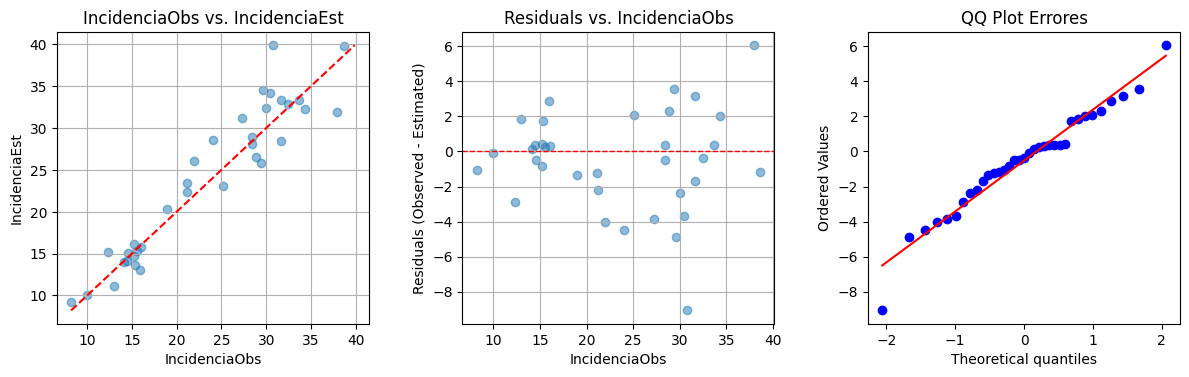

In [11]:
# QQ plot (escenario 1)

def plot_error_provincia_anual(errores, metodo):

  # Filtrar errores del método en ESCENARIO 1
  errores_cleaned = errores[(errores.Metodo==metodo)&(errores.Grupo=='Testing')&(errores.Escenario=='Escenario1')].copy()

  # Create a figure and a set of subplots
  fig, axes = plt.subplots(1, 3, figsize=(12, 5)) # 1 row, 3 columns

  # plot IncidenciaObs (x axis) vs IncidenciaEst (y axis) with line y=x
  axes[0].scatter(errores_cleaned['IncidenciaObs'], errores_cleaned['IncidenciaEst'], alpha=0.5)
  axes[0].set_title('IncidenciaObs vs. IncidenciaEst')
  axes[0].set_xlabel('IncidenciaObs')
  axes[0].set_ylabel('IncidenciaEst')
  axes[0].grid(True)
  # Add y = x line
  min_val = min(errores_cleaned['IncidenciaObs'].min(), errores_cleaned['IncidenciaEst'].min())
  max_val = max(errores_cleaned['IncidenciaObs'].max(), errores_cleaned['IncidenciaEst'].max())
  axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

  # Plot residuals (errors)
  axes[1].scatter(errores_cleaned['IncidenciaObs'], errores_cleaned['Error'], alpha=0.5)
  axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
  axes[1].set_title('Residuals vs. IncidenciaObs')
  axes[1].set_xlabel('IncidenciaObs')
  axes[1].set_ylabel('Residuals (Observed - Estimated)')
  axes[1].grid(True)

  # QQ plot
  stats.probplot(errores_cleaned['Error'], dist="norm", plot=axes[2])
  axes[2].set_title('QQ Plot Errores')

  # Adjust layout to prevent titles and labels from overlapping and a small size
  plt.tight_layout()
  plt.subplots_adjust(top=0.7, wspace=0.3)
  plt.show()

plot_error_provincia_anual(errores, 'EjemploRIM')

Normal distribution fit: mu = -0.519, std = 2.827
Normal distribution S-W test: statistic = 0.970, p-value = 0.451
Normal distribution K-S test: statistic = 0.112, p-value = 0.731


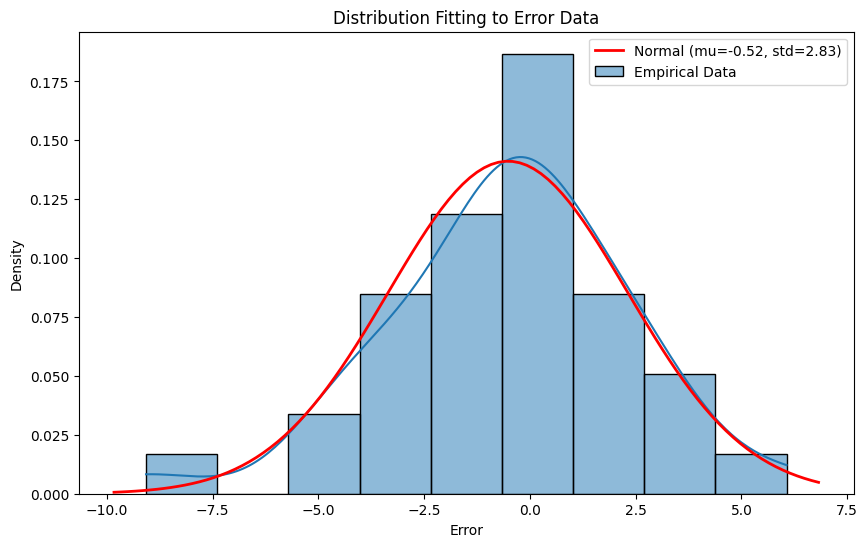


95% Confidence Interval for fitted normal distribution: (np.float64(-6.059347047085551), np.float64(5.020363929301879))


In [12]:
def analyze_error_distribution(errores, metodo):

  errores_cleaned = errores[(errores.Metodo==metodo)&(errores.Grupo=='Testing')&(errores.Escenario=='Escenario1')].copy()
  data = errores_cleaned['Error']

  # Fit Normal distribution
  mu, std = norm.fit(data)
  print(f"Normal distribution fit: mu = {mu:.3f}, std = {std:.3f}")
  # Perform Shapiro-Wilk test for normality
  stat_shapiro, p_value_shapiro = shapiro(data)
  print(f'Normal distribution S-W test: statistic = {stat_shapiro:.3f}, p-value = {p_value_shapiro:.3f}')
  ks_stat_norm, ks_pvalue_norm = kstest(data, 'norm', args=(mu, std))
  print(f"Normal distribution K-S test: statistic = {ks_stat_norm.item():.3f}, p-value = {ks_pvalue_norm.item():.3f}")


  # Visualize the fitted distributions
  plt.figure(figsize=(10, 6))
  sns.histplot(data, kde=True, stat="density", label="Empirical Data")
  xmin, xmax = plt.xlim()
  x = np.linspace(xmin, xmax, 100)
  p_norm = norm.pdf(x, mu, std)
  plt.plot(x, p_norm, 'r', linewidth=2, label=f'Normal (mu={mu:.2f}, std={std:.2f})')
  plt.title("Distribution Fitting to Error Data")
  plt.xlabel("Error")
  plt.ylabel("Density")
  plt.legend()
  plt.show()

  # Calculate 95% confidence interval for the fitted normal distribution
  ci_lower, ci_upper = norm.interval(0.95, loc=mu, scale=std)

  return (ci_lower, ci_upper)

t_ci = analyze_error_distribution(errores, 'EjemploRIM')
print(f"\n95% Confidence Interval for fitted normal distribution: {t_ci}")

In [13]:
# Resumen Errores

def resumen_errores(errores, metodos=None):

  # Filtrar datos de errores
  df = errores.copy()
  if metodos is not None: df = df[df.Metodo.isin(metodos)]

  # Nombres evaluaciones
  df['Evaluación'] = 'Cruzada'
  df.loc[df.Escenario=='Escenario1','Evaluación'] = 'RPCs'

  # Métricas de error
  df1 = df.groupby(['Evaluación','Metodo']).agg({'Provincia':'count','IncidenciaObs':'mean','IncidenciaEst':'mean','Error':'mean','Error2':'mean','ErrorPerc':'mean'})
  df1 = df1.set_axis(['N','IncObs','IncEst','Bias', 'RMSE', 'MAPE'], axis=1)
  df1['RMSE'] = np.sqrt(df1['RMSE'])
  df1['MAPE']=df1['MAPE']*100
  df1 = df1.round(2)

  # Calculate R-squared for each group
  df2 = (df.groupby(['Evaluación', 'Metodo'])[['IncidenciaObs','IncidenciaEst']].
         apply(lambda x: r2_score(x.IncidenciaObs, x.IncidenciaEst)).round(4).
         reset_index(name='R2'))

  return df1.join(df2.set_index(['Evaluación','Metodo']))

print(resumen_errores(errores))


                        N  IncObs  IncEst  Bias  RMSE  MAPE      R2
Evaluación Metodo                                                  
RPCs       EjemploRIM  35   23.32   23.83 -0.52  2.87  8.98  0.8843


## Aplicación Métodos

In [14]:
def aplicar_metodo(nombreMetodo, Ratio, RangoEdad='RangoEdad4080', qqplot=False, **kwargs):

  # Obtener escenarios
  lista_escenarios = escenarios[escenarios.Tipo=='Evaluacion'].Escenario.unique().tolist()

  # Eliminar predicciones anteriores con mismo metodo
  remove_metodo(nombreMetodo)

  # proyectar escenario
  for escenario in lista_escenarios:

    print(escenario)
    data = cargar_datos_escenario(escenario, RangoEdad, **kwargs)
    data = regresion_ratios(data, RangoEdad, Ratio, summary=(True if escenario=='Escenario1' else False), **kwargs)
    guardar_proyecciones(data, RangoEdad, nombreMetodo)

  # wait 3 seconds
  time.sleep(3)
  errores = calcular_errores(nombreMetodo)
  print(resumen_errores(errores, metodos=[nombreMetodo]))
  if qqplot: plot_error_provincia_anual(errores, nombreMetodo) # QQ plot escenario 1

# print function signature
print('Ready',aplicar_metodo)

Ready <function aplicar_metodo at 0x7e6c2c7c9a80>


# ⚖ Evaluacion Métodos

## Modelos Base

In [15]:
# RIM

aplicar_metodo(nombreMetodo='RIM', Ratio='RIM')

0  predicciones previas de RIM eliminadas

Escenario22
Cargando Escenario22  (evaluacion)
Training:  2004 - 2018 [ 83 141 142  21  23  81 151  71  72  73  74]  N= 372
Testing:  2005 - 2014 [22]  N= 48
344 observaciones para entrenamiento,  28  ratios nulos
Modelo:  Defunciones ~ MedianaRangoEdad4080 + s(Provincia, bs="re")
48  predicciones guardadas
---
Escenario21
Cargando Escenario21  (evaluacion)
Training:  2004 - 2018 [ 83 141 142  22  23  81 151  71  72  73  74]  N= 372
Testing:  2005 - 2014 [21]  N= 48
341 observaciones para entrenamiento,  31  ratios nulos
Modelo:  Defunciones ~ MedianaRangoEdad4080 + s(Provincia, bs="re")
48  predicciones guardadas
---
Escenario23
Cargando Escenario23  (evaluacion)
Training:  2004 - 2018 [ 83 141 142  21  22  81 151  71  72  73  74]  N= 372
Testing:  2005 - 2014 [23]  N= 48
356 observaciones para entrenamiento,  16  ratios nulos
Modelo:  Defunciones ~ MedianaRangoEdad4080 + s(Provincia, bs="re")
48  predicciones guardadas
---
Escenario81
Cargan

In [16]:
aplicar_metodo(nombreMetodo='RIMH', Ratio='RIMH')

0  predicciones previas de RIMH eliminadas

Escenario22
Cargando Escenario22  (evaluacion)
Training:  2004 - 2018 [ 83 141 142  21  23  81 151  71  72  73  74]  N= 372
Testing:  2005 - 2014 [22]  N= 48
344 observaciones para entrenamiento,  28  ratios nulos
Modelo:  EgresosDefs ~ MedianaRangoEdad4080 + s(Provincia, bs="re")
48  predicciones guardadas
---
Escenario21
Cargando Escenario21  (evaluacion)
Training:  2004 - 2018 [ 83 141 142  22  23  81 151  71  72  73  74]  N= 372
Testing:  2005 - 2014 [21]  N= 48
341 observaciones para entrenamiento,  31  ratios nulos
Modelo:  EgresosDefs ~ MedianaRangoEdad4080 + s(Provincia, bs="re")
48  predicciones guardadas
---
Escenario23
Cargando Escenario23  (evaluacion)
Training:  2004 - 2018 [ 83 141 142  21  22  81 151  71  72  73  74]  N= 372
Testing:  2005 - 2014 [23]  N= 48
356 observaciones para entrenamiento,  16  ratios nulos
Modelo:  EgresosDefs ~ MedianaRangoEdad4080 + s(Provincia, bs="re")
48  predicciones guardadas
---
Escenario81
Carga

In [17]:
aplicar_metodo(nombreMetodo='RIH', Ratio='RIH')

0  predicciones previas de RIH eliminadas

Escenario22
Cargando Escenario22  (evaluacion)
Training:  2004 - 2018 [ 83 141 142  21  23  81 151  71  72  73  74]  N= 372
Testing:  2005 - 2014 [22]  N= 48
344 observaciones para entrenamiento,  28  ratios nulos
Modelo:  Egresos ~ MedianaRangoEdad4080 + s(Provincia, bs="re")
48  predicciones guardadas
---
Escenario21
Cargando Escenario21  (evaluacion)
Training:  2004 - 2018 [ 83 141 142  22  23  81 151  71  72  73  74]  N= 372
Testing:  2005 - 2014 [21]  N= 48
341 observaciones para entrenamiento,  31  ratios nulos
Modelo:  Egresos ~ MedianaRangoEdad4080 + s(Provincia, bs="re")
48  predicciones guardadas
---
Escenario23
Cargando Escenario23  (evaluacion)
Training:  2004 - 2018 [ 83 141 142  21  22  81 151  71  72  73  74]  N= 372
Testing:  2005 - 2014 [23]  N= 48
356 observaciones para entrenamiento,  16  ratios nulos
Modelo:  Egresos ~ MedianaRangoEdad4080 + s(Provincia, bs="re")
48  predicciones guardadas
---
Escenario81
Cargando Escenario

In [19]:
# @title 📊 Tabla 5: internal validation

metodos_resumen = ['RIM','RIMH','RIH']

print(resumen_errores(calcular_errores(), metodos=metodos_resumen).reindex(metodos_resumen, level='Metodo'))

                    N  IncObs  IncEst  Bias  RMSE   MAPE      R2
Evaluación Metodo                                               
Cruzada    RIM     35   23.32   23.85 -0.53  2.93   9.21  0.8798
           RIMH    35   23.32   23.90 -0.59  3.92  11.70  0.7847
           RIH     35   23.32   25.54 -2.22  6.64  20.12  0.3813
RPCs       RIM     35   23.32   23.83 -0.52  2.87   8.98  0.8843
           RIMH    35   23.32   24.00 -0.68  3.85  11.49  0.7927
           RIH     35   23.32   26.03 -2.71  7.20  20.94  0.2743


## Modelos con covariables

In [20]:
# RIM  + covariables

aplicar_metodo(nombreMetodo='RIMcovs', Ratio='RIM', covariables=['Sexo', 'Ruralidad','PorcA','PorcB','PorcC','PorcD','PorcIsapre','Periodo']) #
aplicar_metodo(nombreMetodo='RIMcovs', Ratio='RIM', covariables=['Sexo', 'Ruralidad','PorcA','PorcB','PorcC','PorcD','Periodo']) # 'PorcIsapre'
aplicar_metodo(nombreMetodo='RIMcovs', Ratio='RIM', covariables=['Sexo', 'Ruralidad','PorcA','PorcB','PorcC','PorcD']) # 'PorcIsapre','Periodo'
aplicar_metodo(nombreMetodo='RIMcovs', Ratio='RIM', covariables=['Sexo', 'Ruralidad','PorcA','PorcB','PorcD']) # 'PorcIsapre','Periodo','PorcC'
aplicar_metodo(nombreMetodo='RIMcovs', Ratio='RIM', covariables=['Sexo', 'Ruralidad','PorcA','PorcB']) # 'PorcIsapre','Periodo','PorcC','PorcD'
aplicar_metodo(nombreMetodo='RIMcovs', Ratio='RIM', covariables=['Sexo', 'Ruralidad','PorcA']) # 'PorcIsapre','Periodo','PorcC','PorcD','PorcB'

0  predicciones previas de RIMcovs eliminadas

Escenario22
Cargando Escenario22  (evaluacion)
Training:  2004 - 2018 [ 83 141 142  21  23  81 151  71  72  73  74]  N= 372
Testing:  2005 - 2014 [22]  N= 48
344 observaciones para entrenamiento,  28  ratios nulos
Modelo:  Defunciones ~ MedianaRangoEdad4080 + Sexo + Ruralidad + PorcA + PorcB + PorcC + PorcD + PorcIsapre + Periodo + s(Provincia, bs="re")
48  predicciones guardadas
---
Escenario21
Cargando Escenario21  (evaluacion)
Training:  2004 - 2018 [ 83 141 142  22  23  81 151  71  72  73  74]  N= 372
Testing:  2005 - 2014 [21]  N= 48
341 observaciones para entrenamiento,  31  ratios nulos
Modelo:  Defunciones ~ MedianaRangoEdad4080 + Sexo + Ruralidad + PorcA + PorcB + PorcC + PorcD + PorcIsapre + Periodo + s(Provincia, bs="re")
48  predicciones guardadas
---
Escenario23
Cargando Escenario23  (evaluacion)
Training:  2004 - 2018 [ 83 141 142  21  22  81 151  71  72  73  74]  N= 372
Testing:  2005 - 2014 [23]  N= 48
356 observaciones par

In [21]:
aplicar_metodo(nombreMetodo='RIMHcovs', Ratio='RIMH', covariables=['Sexo', 'Ruralidad','PorcA','PorcB','PorcC','PorcD','PorcIsapre','Periodo']) #
aplicar_metodo(nombreMetodo='RIMHcovs', Ratio='RIMH', covariables=['Sexo', 'Ruralidad','PorcA','PorcB','PorcC','PorcD','Periodo']) # 'PorcIsapre',
aplicar_metodo(nombreMetodo='RIMHcovs', Ratio='RIMH', covariables=['Sexo', 'Ruralidad','PorcA','PorcB','PorcD','Periodo']) # 'PorcIsapre','PorcC',
aplicar_metodo(nombreMetodo='RIMHcovs', Ratio='RIMH', covariables=['Sexo', 'Ruralidad','PorcA','PorcB','Periodo']) # 'PorcIsapre','PorcC','PorcD',
aplicar_metodo(nombreMetodo='RIMHcovs', Ratio='RIMH', covariables=['Sexo', 'Ruralidad','PorcA','PorcB']) # 'PorcIsapre','PorcC','PorcD','Periodo',
aplicar_metodo(nombreMetodo='RIMHcovs', Ratio='RIMH', covariables=['Sexo', 'Ruralidad','PorcB']) # 'PorcIsapre','PorcC','PorcD','Periodo','PorcA',
aplicar_metodo(nombreMetodo='RIMHcovs', Ratio='RIMH', covariables=['Ruralidad','PorcB']) # 'PorcIsapre','PorcC','PorcD','Periodo','PorcA','Sexo',

0  predicciones previas de RIMHcovs eliminadas

Escenario22
Cargando Escenario22  (evaluacion)
Training:  2004 - 2018 [ 83 141 142  21  23  81 151  71  72  73  74]  N= 372
Testing:  2005 - 2014 [22]  N= 48
344 observaciones para entrenamiento,  28  ratios nulos
Modelo:  EgresosDefs ~ MedianaRangoEdad4080 + Sexo + Ruralidad + PorcA + PorcB + PorcC + PorcD + PorcIsapre + Periodo + s(Provincia, bs="re")
48  predicciones guardadas
---
Escenario21
Cargando Escenario21  (evaluacion)
Training:  2004 - 2018 [ 83 141 142  22  23  81 151  71  72  73  74]  N= 372
Testing:  2005 - 2014 [21]  N= 48
341 observaciones para entrenamiento,  31  ratios nulos
Modelo:  EgresosDefs ~ MedianaRangoEdad4080 + Sexo + Ruralidad + PorcA + PorcB + PorcC + PorcD + PorcIsapre + Periodo + s(Provincia, bs="re")
48  predicciones guardadas
---
Escenario23
Cargando Escenario23  (evaluacion)
Training:  2004 - 2018 [ 83 141 142  21  22  81 151  71  72  73  74]  N= 372
Testing:  2005 - 2014 [23]  N= 48
356 observaciones pa

In [22]:
aplicar_metodo(nombreMetodo='RIHcovs', Ratio='RIH', covariables=['Sexo', 'Ruralidad','PorcA','PorcB','PorcC','PorcD','PorcIsapre','Periodo']) #
aplicar_metodo(nombreMetodo='RIHcovs', Ratio='RIH', covariables=['Sexo', 'Ruralidad','PorcA','PorcB','PorcC','PorcIsapre','Periodo']) # 'PorcD',
aplicar_metodo(nombreMetodo='RIHcovs', Ratio='RIH', covariables=['Ruralidad','PorcA','PorcB','PorcC','PorcIsapre','Periodo']) # 'PorcD','Sexo',
aplicar_metodo(nombreMetodo='RIHcovs', Ratio='RIH', covariables=['Ruralidad','PorcA','PorcB','PorcC','PorcIsapre']) # 'PorcD','Sexo','Periodo',
aplicar_metodo(nombreMetodo='RIHcovs', Ratio='RIH', covariables=['Ruralidad','PorcB','PorcC','PorcIsapre']) # 'PorcD','Sexo','Periodo', 'PorcA',
aplicar_metodo(nombreMetodo='RIHcovs', Ratio='RIH', covariables=['Ruralidad','PorcB','PorcIsapre']) # 'PorcD','Sexo','Periodo', 'PorcA','PorcC',
aplicar_metodo(nombreMetodo='RIHcovs', Ratio='RIH', covariables=['PorcB','PorcIsapre']) # 'PorcD','Sexo','Periodo', 'PorcA','PorcC','Ruralidad',
aplicar_metodo(nombreMetodo='RIHcovs', Ratio='RIH', covariables=['PorcB']) # 'PorcD','Sexo','Periodo', 'PorcA','PorcC','Ruralidad','PorcIsapre',
# Coeficiente de PorcB no es estadísticamente significativo

0  predicciones previas de RIHcovs eliminadas

Escenario22
Cargando Escenario22  (evaluacion)
Training:  2004 - 2018 [ 83 141 142  21  23  81 151  71  72  73  74]  N= 372
Testing:  2005 - 2014 [22]  N= 48
344 observaciones para entrenamiento,  28  ratios nulos
Modelo:  Egresos ~ MedianaRangoEdad4080 + Sexo + Ruralidad + PorcA + PorcB + PorcC + PorcD + PorcIsapre + Periodo + s(Provincia, bs="re")
48  predicciones guardadas
---
Escenario21
Cargando Escenario21  (evaluacion)
Training:  2004 - 2018 [ 83 141 142  22  23  81 151  71  72  73  74]  N= 372
Testing:  2005 - 2014 [21]  N= 48
341 observaciones para entrenamiento,  31  ratios nulos
Modelo:  Egresos ~ MedianaRangoEdad4080 + Sexo + Ruralidad + PorcA + PorcB + PorcC + PorcD + PorcIsapre + Periodo + s(Provincia, bs="re")
48  predicciones guardadas
---
Escenario23
Cargando Escenario23  (evaluacion)
Training:  2004 - 2018 [ 83 141 142  21  22  81 151  71  72  73  74]  N= 372
Testing:  2005 - 2014 [23]  N= 48
356 observaciones para entren

In [24]:
#@title 📊 Material Sup 9a: internal validation
print(resumen_errores(calcular_errores(), metodos=['RIMcovs','RIMHcovs','RIHcovs']).reindex(['RIMcovs','RIMHcovs','RIHcovs'], level='Metodo'))

                      N  IncObs  IncEst  Bias  RMSE   MAPE      R2
Evaluación Metodo                                                 
Cruzada    RIMcovs   35   23.32   22.22  1.09  3.12   8.90  0.8633
           RIMHcovs  35   23.32   22.29  1.02  3.84  12.11  0.7935
           RIHcovs   35   23.32   25.27 -1.95  6.56  19.66  0.3978
RPCs       RIMcovs   35   23.32   22.36  0.96  2.81   7.75  0.8894
           RIMHcovs  35   23.32   23.00  0.31  3.53  10.62  0.8254
           RIHcovs   35   23.32   25.73 -2.41  6.97  20.11  0.3194


## Estimaciones Chile
Estimar incidencia para todas las provincias de Chile en el periodo 2003-2024

In [25]:
def proyectar_incidencia_Chile(nombreMetodo, Ratio, RangoEdad='RangoEdad4080', filter_sexo=None, **kwargs):

  data = cargar_datos_escenario('Chile', RangoEdad, **kwargs)
  if filter_sexo: data = data[data.Sexo==filter_sexo]
  data = regresion_ratios(data, RangoEdad, Ratio, summary=True, **kwargs)
  guardar_proyecciones(data, RangoEdad, nombreMetodo)


In [26]:
# RIM hombres
proyectar_incidencia_Chile(nombreMetodo='RIMclHombres', Ratio='RIM', filter_sexo='Hombre')

# RIM mujeres
proyectar_incidencia_Chile(nombreMetodo='RIMclMujeres', Ratio='RIM', filter_sexo='Mujer')

Cargando Chile  (proyección)
Training:  2004 - 2018 [ 83 141 142  21  22  23  81 151  71  72  73  74]  N= 420
Testing:  2004 - 2023 [   11    14    21    22    23    31    32    33    41    42    43    51
    52    53    54    55    56    57    58    61    62    63    71    72
    73    74    81    82    83    91    92   101   102   103   104   111
   112   113   114   121   123   124   132   133   134   135   136   141
   142   151   152   161   162   163 13109 13110 13111 13112 13113 13114]  N= 5040
200 observaciones para entrenamiento,  10  ratios nulos
Modelo:  Defunciones ~ MedianaRangoEdad4080 + s(Provincia, bs="re")

Family: quasipoisson 
Link function: log 

Formula:
Defunciones ~ MedianaRangoEdad4080 + s(Provincia, bs = "re")

Parametric coefficients:
                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)          -0.939602   0.072439  -12.97   <2e-16 ***
MedianaRangoEdad4080  0.010866   0.001009   10.77   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0

In [27]:
# RIMH
proyectar_incidencia_Chile(nombreMetodo='RIMHcl', Ratio='RIMH')

Cargando Chile  (proyección)
Training:  2004 - 2018 [ 83 141 142  21  22  23  81 151  71  72  73  74]  N= 420
Testing:  2004 - 2023 [   11    14    21    22    23    31    32    33    41    42    43    51
    52    53    54    55    56    57    58    61    62    63    71    72
    73    74    81    82    83    91    92   101   102   103   104   111
   112   113   114   121   123   124   132   133   134   135   136   141
   142   151   152   161   162   163 13109 13110 13111 13112 13113 13114]  N= 5040
389 observaciones para entrenamiento,  31  ratios nulos
Modelo:  EgresosDefs ~ MedianaRangoEdad4080 + s(Provincia, bs="re")

Family: quasipoisson 
Link function: log 

Formula:
EgresosDefs ~ MedianaRangoEdad4080 + s(Provincia, bs = "re")

Parametric coefficients:
                       Estimate Std. Error t value Pr(>|t|)  
(Intercept)          -0.0197259  0.0576435  -0.342   0.7324  
MedianaRangoEdad4080  0.0017885  0.0007705   2.321   0.0208 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01

In [28]:
# RIH
proyectar_incidencia_Chile(nombreMetodo='RIHcl', Ratio='RIH')

Cargando Chile  (proyección)
Training:  2004 - 2018 [ 83 141 142  21  22  23  81 151  71  72  73  74]  N= 420
Testing:  2004 - 2023 [   11    14    21    22    23    31    32    33    41    42    43    51
    52    53    54    55    56    57    58    61    62    63    71    72
    73    74    81    82    83    91    92   101   102   103   104   111
   112   113   114   121   123   124   132   133   134   135   136   141
   142   151   152   161   162   163 13109 13110 13111 13112 13113 13114]  N= 5040
389 observaciones para entrenamiento,  31  ratios nulos
Modelo:  Egresos ~ MedianaRangoEdad4080 + s(Provincia, bs="re")

Family: quasipoisson 
Link function: log 

Formula:
Egresos ~ MedianaRangoEdad4080 + s(Provincia, bs = "re")

Parametric coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)           0.2883589  0.0740300   3.895 0.000116 ***
MedianaRangoEdad4080 -0.0101956  0.0009803 -10.400  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘

In [29]:
# Covariables

for ratio in ['RIM', 'RIMH']:
  proyectar_incidencia_Chile(nombreMetodo = (ratio+'covscl'),
                             Ratio=ratio,
                             covariables=(['Sexo', 'Ruralidad','PorcA'] if ratio=='RIM' else ['Ruralidad','PorcB']))


Cargando Chile  (proyección)
Training:  2004 - 2018 [ 83 141 142  21  22  23  81 151  71  72  73  74]  N= 420
Testing:  2004 - 2023 [   11    14    21    22    23    31    32    33    41    42    43    51
    52    53    54    55    56    57    58    61    62    63    71    72
    73    74    81    82    83    91    92   101   102   103   104   111
   112   113   114   121   123   124   132   133   134   135   136   141
   142   151   152   161   162   163 13109 13110 13111 13112 13113 13114]  N= 5040
389 observaciones para entrenamiento,  31  ratios nulos
Modelo:  Defunciones ~ MedianaRangoEdad4080 + Sexo + Ruralidad + PorcA + s(Provincia, bs="re")

Family: quasipoisson 
Link function: log 

Formula:
Defunciones ~ MedianaRangoEdad4080 + Sexo + Ruralidad + PorcA + 
    s(Provincia, bs = "re")

Parametric coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)          -1.0233962  0.0630604 -16.229  < 2e-16 ***
MedianaRangoEdad4080  0.0117791  0.0008229

In [30]:
#Cargar Estimaciones Chile

def calcular_incidencia_provincias(niveles=None):

  # cargar estimaciones Chile
  predicciones = (pd.read_parquet(path_output + 'Predicciones.parquet').
                  query('Escenario=="Chile" & Grupo=="Testing"'))

  # calcular casos
  predicciones['Casos'] = predicciones.IncidenciaEst * predicciones.Poblacion / HABS
  # agregar casos al nivel definido
  niveles += ['Periodo']
  predicciones = (predicciones.groupby(niveles)[['Casos','Poblacion']].sum())
  # calcular incidencia
  predicciones['IncidenciaEst'] = predicciones.Casos / predicciones.Poblacion * HABS
  return predicciones.reset_index()

calcular_incidencia_provincias(niveles=['Metodo','Sexo']).\
pivot(index='Periodo', columns=['Metodo','Sexo'], values='IncidenciaEst').tail(5)

Metodo       RIHcl                RIMHcl            RIMHcovscl             \
Sexo        Hombre      Mujer     Hombre      Mujer     Hombre      Mujer   
Periodo                                                                     
2011     32.181791  16.142043  30.067319  15.547272  29.093243  14.897626   
2014     31.412323  15.865494  28.999316  15.246240  28.020100  14.572454   
2017     31.193292  15.593251  28.445792  14.591642  27.970037  14.230053   
2020     27.240051  13.705665  25.252356  13.193851  24.841804  12.864506   
2023     28.469878  14.662642  25.580792  13.714926  25.162473  13.347218   

Metodo  RIMclHombres RIMclMujeres  RIMcovscl             
Sexo          Hombre        Mujer     Hombre      Mujer  
Periodo                                                  
2011       31.301609    15.743266  30.213464  15.214222  
2014       29.827147    15.131277  28.860418  14.627403  
2017       28.276456    14.103975  27.002260  13.600010  
2020       25.490528    12.916610  24.347470  12.488764  
2023       24.250198    12.617167  23.143481  12.165496

## Comparación IARC 2003-2022

In [31]:
# Cargar datos para comparar incidencia estimada vs iarc (por año y sexo)

def data_comparacion_incidencias_nac(pobEstandar=True, periodo=range(2003,2018), metodos=None, **kwargs):

  # Obtener incidencia cruda por sexo-método
  inc = calcular_incidencia_provincias(niveles=['Metodo','Sexo','RangoEdad4080'])
  # Filtrar periodo y métodos
  inc = inc[inc.Metodo.isin(metodos) & inc.Periodo.isin(periodo)]
  inc.loc[inc.Metodo.isin(['RIMclHombres','RIMclMujeres']),'Metodo']='RIMcl'
  inc.loc[inc.Metodo.isin(['RIMcovsclHombres','RIMcovsclMujeres']),'Metodo']='RIMcovscl'
  # Calcular incidencia ambos sexos
  ambos = inc.groupby(['Metodo','Periodo','RangoEdad4080'])[['Casos','Poblacion']].sum().reset_index()
  ambos['IncidenciaEst'] = ambos.Casos / ambos.Poblacion * HABS
  ambos.insert(0,'Sexo','Ambos')
  inc = pd.concat([inc, ambos]).reset_index(drop=False)

  # calcular incidencia estandarizada
  inc = inc.merge(poblacion_estandar, on='RangoEdad4080', how='left')
  # calcular casos en poblacion OMS
  inc['Casos'] = inc.IncidenciaEst * inc.PoblacionOMS / HABS
  inc = inc.groupby(['Metodo','Periodo','Sexo'])[['Casos','PoblacionOMS']].sum().reset_index()
  # calcular incidencia en poblacion OMS
  inc['IncidenciaEst'] = inc.Casos / inc.PoblacionOMS * HABS

  # Agregar estimación IARC por sexo-año
  inc = (inc.merge(incidenciaIARC,how='left',on=['Periodo','Sexo'])
         [['Metodo','Sexo','Año','Periodo','IncidenciaEst','IncidenciaIARC']])

  return inc

incEstIARC = data_comparacion_incidencias_nac(Grupo='Testing', pobEstandar=True,
                                              metodos=['RIMclHombres','RIMclMujeres','RIMHcl','RIHcl',
                                                       'RIMcovscl','RIMHcovscl','RIHcovscl'],
                                              periodo=range(2003,2025))
incEstIARC

,Metodo,Sexo,Año,Periodo,IncidenciaEst,IncidenciaIARC
0,RIHcl,Ambos,2003.0,2004,26.262060,26.424614
1,RIHcl,Ambos,2004.0,2004,26.262060,25.425949
2,RIHcl,Ambos,2005.0,2004,26.262060,20.079171
3,RIHcl,Hombre,2003.0,2004,39.232373,40.615410
4,RIHcl,Hombre,2004.0,2004,39.232373,38.216309
...,...,...,...,...,...,...
250,RIMcovscl,Hombre,NaN,2020,19.412458,NaN
251,RIMcovscl,Mujer,NaN,2020,8.214061,NaN
252,RIMcovscl,Ambos,2022.0,2023,11.775507,14.200000
253,RIMcovscl,Hombre,2022.0,2023,17.025952,21.800000


In [33]:
print('Reducción periodos 2004-2023:',
      incEstIARC[lambda x: ((x.Metodo=='RIMcl') & (x.Sexo=='Ambos') & (x.Periodo.isin([2004,2023])))][['Periodo','IncidenciaEst']].drop_duplicates().set_index('Periodo').apply(lambda x: x.loc[2023]/x.loc[2004]*100))

incEstIARC[lambda x: ((x.Metodo=='RIMcl') & (x.Sexo=='Ambos'))].groupby('Periodo')[['IncidenciaEst','IncidenciaIARC']].mean().round(1).T

Reducción periodos 2004-2023: IncidenciaEst    52.152463
dtype: float64


Periodo,2004,2007,2011,2014,2017,2020,2023
IncidenciaEst,23.6,21.3,20.3,17.9,15.8,13.8,12.3
IncidenciaIARC,24.0,22.8,22.3,20.6,20.8,NaN,14.2


In [35]:
#@title 📊 Tabla 5: external validation

def tabla5(data, metodos):
  print('\nIncidencia 2003-2022 promedio estimada vs IARC')

  df = (data[data.Metodo.isin(metodos) & data.IncidenciaIARC.notna()].
        groupby(['Metodo','Sexo'])[['IncidenciaEst','IncidenciaIARC']].mean().reset_index())
  df['Ratio'] = df.Metodo.str[:-2] #quitar 'cl'
  df['Bias'] = df.IncidenciaIARC.astype(float) - df.IncidenciaEst.astype(float)

  # Cambiar estructura tabla
  df = (df[['Ratio','Sexo','IncidenciaEst','IncidenciaIARC','Bias']].round(2).
        melt(id_vars=['Ratio','Sexo'],
             value_vars=['IncidenciaEst','IncidenciaIARC','Bias'],
             var_name='Metric',
             value_name='Value').reset_index().
        pivot(index=['Metric','Sexo'], columns=['Ratio'], values='Value'))

  return df

tabla5(incEstIARC.copy(), ['RIMcl','RIMHcl','RIHcl'])


Incidencia 2003-2022 promedio estimada vs IARC


Ratio                    RIH    RIM   RIMH
Metric         Sexo                       
Bias           Ambos    0.56   2.10   1.60
               Hombre   0.92   2.89   2.54
               Mujer   -0.54   0.67   0.03
IncidenciaEst  Ambos   21.13  19.60  20.09
               Hombre  31.65  29.68  30.03
               Mujer   13.02  11.81  12.46
IncidenciaIARC Ambos   21.69  21.69  21.69
               Hombre  32.57  32.57  32.57
               Mujer   12.48  12.48  12.48

In [37]:
# Métodos con covariables
#@title 📊 Material Sup 9a (external validation)

tabla5(incEstIARC.copy(), ['RIMcovscl','RIMHcovscl'])


Incidencia 2003-2022 promedio estimada vs IARC


Ratio                  RIMHcovs  RIMcovs
Metric         Sexo                     
Bias           Ambos       2.30     2.81
               Hombre      3.52     4.00
               Mujer       0.53     1.13
IncidenciaEst  Ambos      19.40    18.88
               Hombre     29.05    28.57
               Mujer      11.96    11.35
IncidenciaIARC Ambos      21.69    21.69
               Hombre     32.57    32.57
               Mujer      12.48    12.48

In [38]:
#@title Series de tiempo IncidenciaEst vs IARC

def plot_incidencia_iarc(data, poblacionEstandar=True):
  # Determine the column for IARC data
  iarc_col = 'IncidenciaIARC' if poblacionEstandar else 'IncidenciaCruda'

  unique_sexes = data['Sexo'].unique()
  num_cols = len(unique_sexes)

  # Create subplots
  fig, axes = plt.subplots(1, num_cols, figsize=(num_cols * 6, 4), sharey=True)
  if num_cols == 1: # Ensure axes is always iterable
        axes = [axes]

  # Assign distinct colors for each sex
  sex_colors = sns.color_palette('tab10', n_colors=num_cols)
  sex_color_map = dict(zip(unique_sexes, sex_colors))

  # Add traces for each sex
  for i, sex in enumerate(unique_sexes):
      ax = axes[i]
      sex_data = data[data['Sexo'] == sex].copy() # Make a copy to avoid SettingWithCopyWarning
      sex_data["Año"] = sex_data["Año"].astype('Int64') # Convert Año to integer for integer labels

      current_color = sex_color_map.get(sex, 'gray')

      # Plot IncidenciaEst as a line
      sns.lineplot(x=sex_data["Año"], y=sex_data["IncidenciaEst"], ax=ax, label=f'Modelo ({sex})', color=current_color, linestyle='-')

      # Plot IARC data as markers
      sns.scatterplot(x=sex_data["Año"], y=sex_data[iarc_col], ax=ax, label=f'IARC ({sex})', color=current_color, marker='o', s=50)

      ax.set_title(f'Sexo: {sex}')
      ax.set_xlabel('Año')
      ax.set_ylabel('Incidencia' if i == 0 else '')
      ax.legend(title='Fuente', loc='upper right')
      ax.grid(True, linestyle='--', alpha=0.7)

      # Ensure x-axis labels are integers
      ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

  fig.suptitle(f'Incidencia por sexo ({data.Metodo.iloc[0]})', y=1.02, fontsize=16)
  plt.tight_layout(rect=[0, 0, 1, 0.98])
  plt.show()

def regresion_incidencias_comparadas(data, metodo, sexo='Hombre'):

  # cargar datos
  data = data[(data.Sexo==sexo)&(data.Año.isin(range(2003,2025)))]
  data = data.melt(id_vars=['Sexo','Año'], var_name='Estimacion', value_name='Incidencia', value_vars=['IncidenciaEst','IncidenciaIARC'])

  # transformar variables
  data.loc[data.Estimacion=='IncidenciaEst','Estimacion'] = 'Modelo'
  data.loc[data.Estimacion=='IncidenciaIARC','Estimacion'] = 'IARC'

  # fit linear regression model Incidencia ~ Año + Estimacion
  y = data['Incidencia'].astype(float)
  X = sm.add_constant((data['Año']-data['Año'].min()).astype(int))
  X = pd.concat([X, pd.get_dummies(data['Estimacion']).drop(columns='Modelo')], axis=1).astype(int) # Convert to float after getting dummies
  model = sm.regression.linear_model.GLS(y, X).fit()
  print(f'Diferencia IARC-modelo serie {sexo}: {model.params.IARC.round(2)} (p-valor {model.pvalues.IARC.round(3)})')


def comparar_series(metodo):
    df = incEstIARC[incEstIARC.Metodo==metodo].copy()
    print(metodo+'\n', df.pivot_table(index='Sexo',values=['IncidenciaEst','IncidenciaIARC'],aggfunc='mean'))
    regresion_incidencias_comparadas(df, metodo, sexo='Ambos')
    regresion_incidencias_comparadas(df, metodo, sexo='Hombre')
    regresion_incidencias_comparadas(df, metodo, sexo='Mujer')
    plot_incidencia_iarc(df)


Fit a Generalized Least Squares (GLS) linear regression model:

$ \text{Incidencia} = \beta_0 + \beta_1 (\text{Año} - \text{min(Año)}) + \beta_2 \text{Estimacion}_{\text{IARC}} + \epsilon $

Where:

- $  $$ \text{Incidencia} $ is the dependent variable (the value from the 'Incidencia' column).
- $ \beta_0 $ is the intercept.
- $ \beta_1 $ is the coefficient for the centered 'Año' variable.
- $ (\text{Año} - \text{min(Año)}) $$ (\text{Año} - \text{min(Año)}) $ is the centered year variable.
- $ \beta_2 $$ \beta_2 $ is the coefficient for the 'Estimacion' being 'IARC'.
- $ \text{Estimacion}_{\text{IARC}} $ is a dummy variable that is 1 if the estimation is 'IARC' and 0 if it is 'Modelo' (the reference category).
- $ \epsilon $ is the error term, which in GLS can have a non-diagonal covariance matrix to account for heteroscedasticity or autocorrelation.

The model estimates how 'Incidencia' changes with the year and whether the estimation method is 'IARC' compared to 'Modelo'. The difference in incidence between 'IARC' and 'Modelo', after accounting for the effect of the year, is represented by the coefficient $ \beta_2 $.

RIMcl
         IncidenciaEst  IncidenciaIARC
Sexo                                 
Ambos       19.252735       21.694851
Hombre      29.132106       32.574238
Mujer       11.620071       12.481371
Diferencia IARC-modelo serie Ambos: 2.1 (p-valor 0.001)
Diferencia IARC-modelo serie Hombre: 2.89 (p-valor 0.015)
Diferencia IARC-modelo serie Mujer: 0.67 (p-valor 0.032)


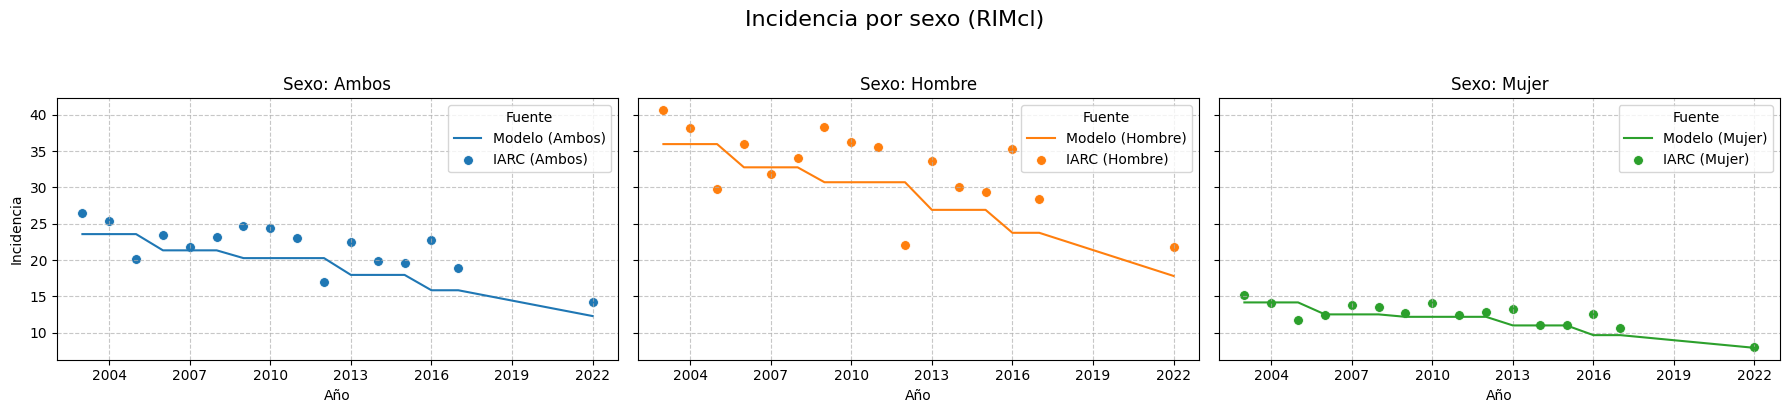

In [39]:
comparar_series('RIMcl')

RIMHcl
         IncidenciaEst  IncidenciaIARC
Sexo                                 
Ambos       19.722652       21.694851
Hombre      29.445537       32.574238
Mujer       12.235952       12.481371
Diferencia IARC-modelo serie Ambos: 1.6 (p-valor 0.021)
Diferencia IARC-modelo serie Hombre: 2.54 (p-valor 0.04)
Diferencia IARC-modelo serie Mujer: 0.03 (p-valor 0.944)


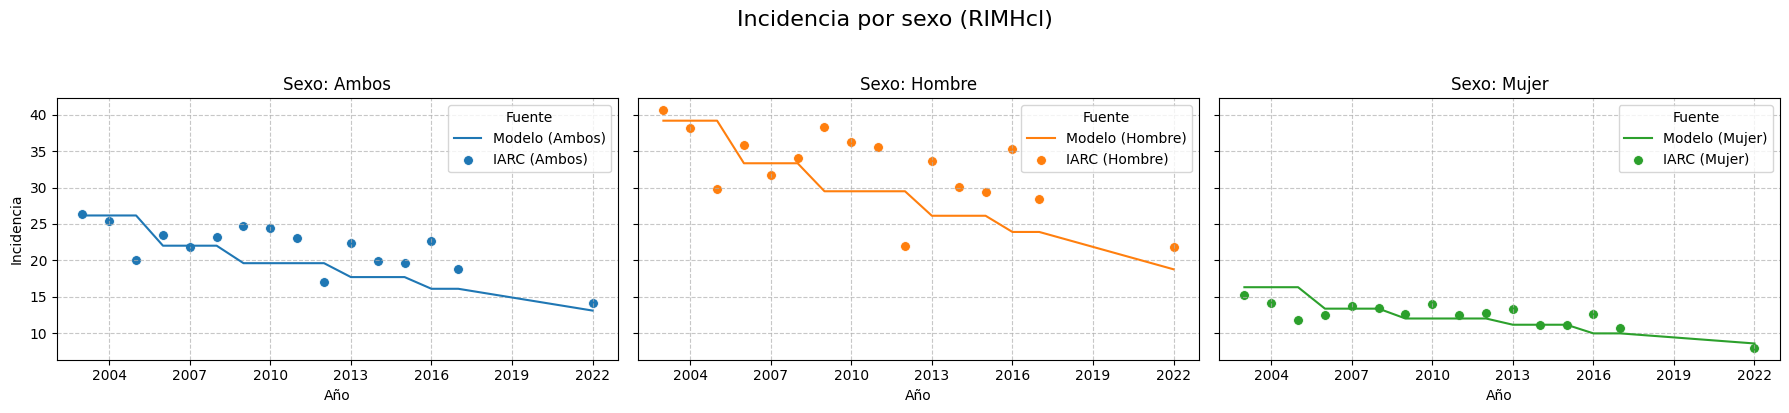

In [40]:
comparar_series('RIMHcl')

RIHcl
         IncidenciaEst  IncidenciaIARC
Sexo                                 
Ambos       20.758397       21.694851
Hombre      31.063103       32.574238
Mujer       12.797187       12.481371
Diferencia IARC-modelo serie Ambos: 0.56 (p-valor 0.367)
Diferencia IARC-modelo serie Hombre: 0.92 (p-valor 0.417)
Diferencia IARC-modelo serie Mujer: -0.54 (p-valor 0.114)


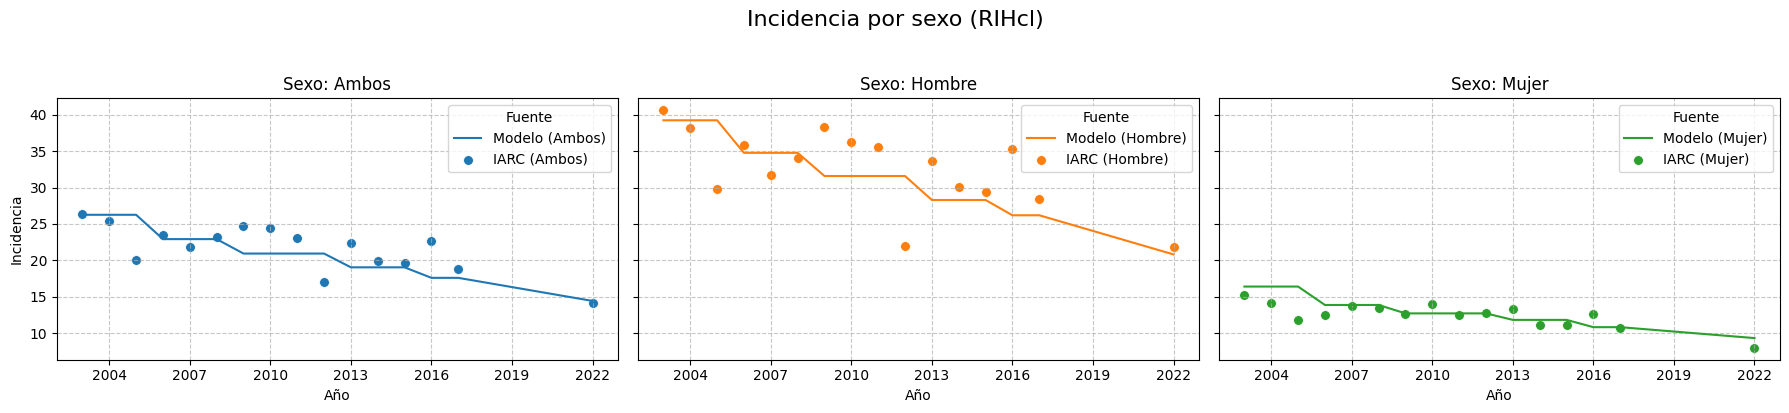

In [41]:
comparar_series('RIHcl')